# Eksperimen Machine Learning - Wine Quality Classification
## Template Eksperimen MSML

**Nama:** I Kadek Rai Pramana

**Dataset:** Wine Quality (Red) - UCI ML Repository

**Tujuan:** Melakukan eksperimen preprocessing dan eksplorasi data untuk klasifikasi kualitas wine (binary classification: Good vs Not Good)

---
## 1. Data Loading
Pada tahap ini kita akan memuat dataset Wine Quality dari UCI ML Repository.

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Setting visualisasi
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print('Library berhasil diimport!')

Library berhasil diimport!


In [2]:
# Load dataset
df = pd.read_csv('../wine_quality_raw.csv', sep=';')

print(f'Dataset shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print()
df.head(10)

Dataset shape: (1599, 12)
Jumlah baris: 1599
Jumlah kolom: 12



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [3]:
# Informasi dataset
print('=== Dataset Info ===')
df.info()
print()
print('=== Deskripsi Statistik ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

=== Deskripsi Statistik ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
# Cek missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


In [5]:
# Cek duplikat
duplicates = df.duplicated().sum()
print(f'Jumlah baris duplikat: {duplicates}')
print(f'Persentase duplikat: {duplicates/len(df)*100:.2f}%')

Jumlah baris duplikat: 240
Persentase duplikat: 15.01%


---
## 2. Exploratory Data Analysis (EDA)
Pada tahap ini kita akan melakukan eksplorasi data untuk memahami distribusi, korelasi, dan pola dalam dataset.

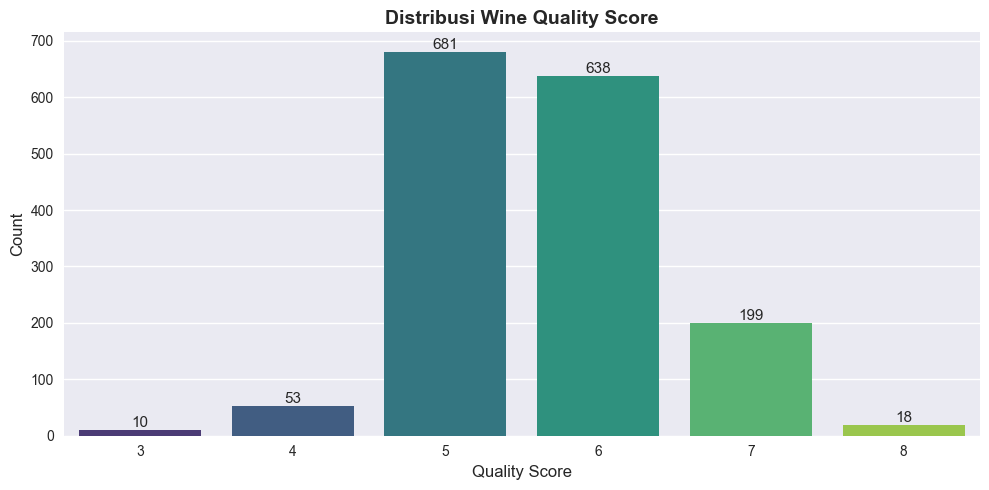


Distribusi Quality:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [6]:
# Distribusi target variable (quality)
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='quality', palette='viridis')
plt.title('Distribusi Wine Quality Score', fontsize=14, fontweight='bold')
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Tambahkan label count di atas bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print('\nDistribusi Quality:')
print(df['quality'].value_counts().sort_index())

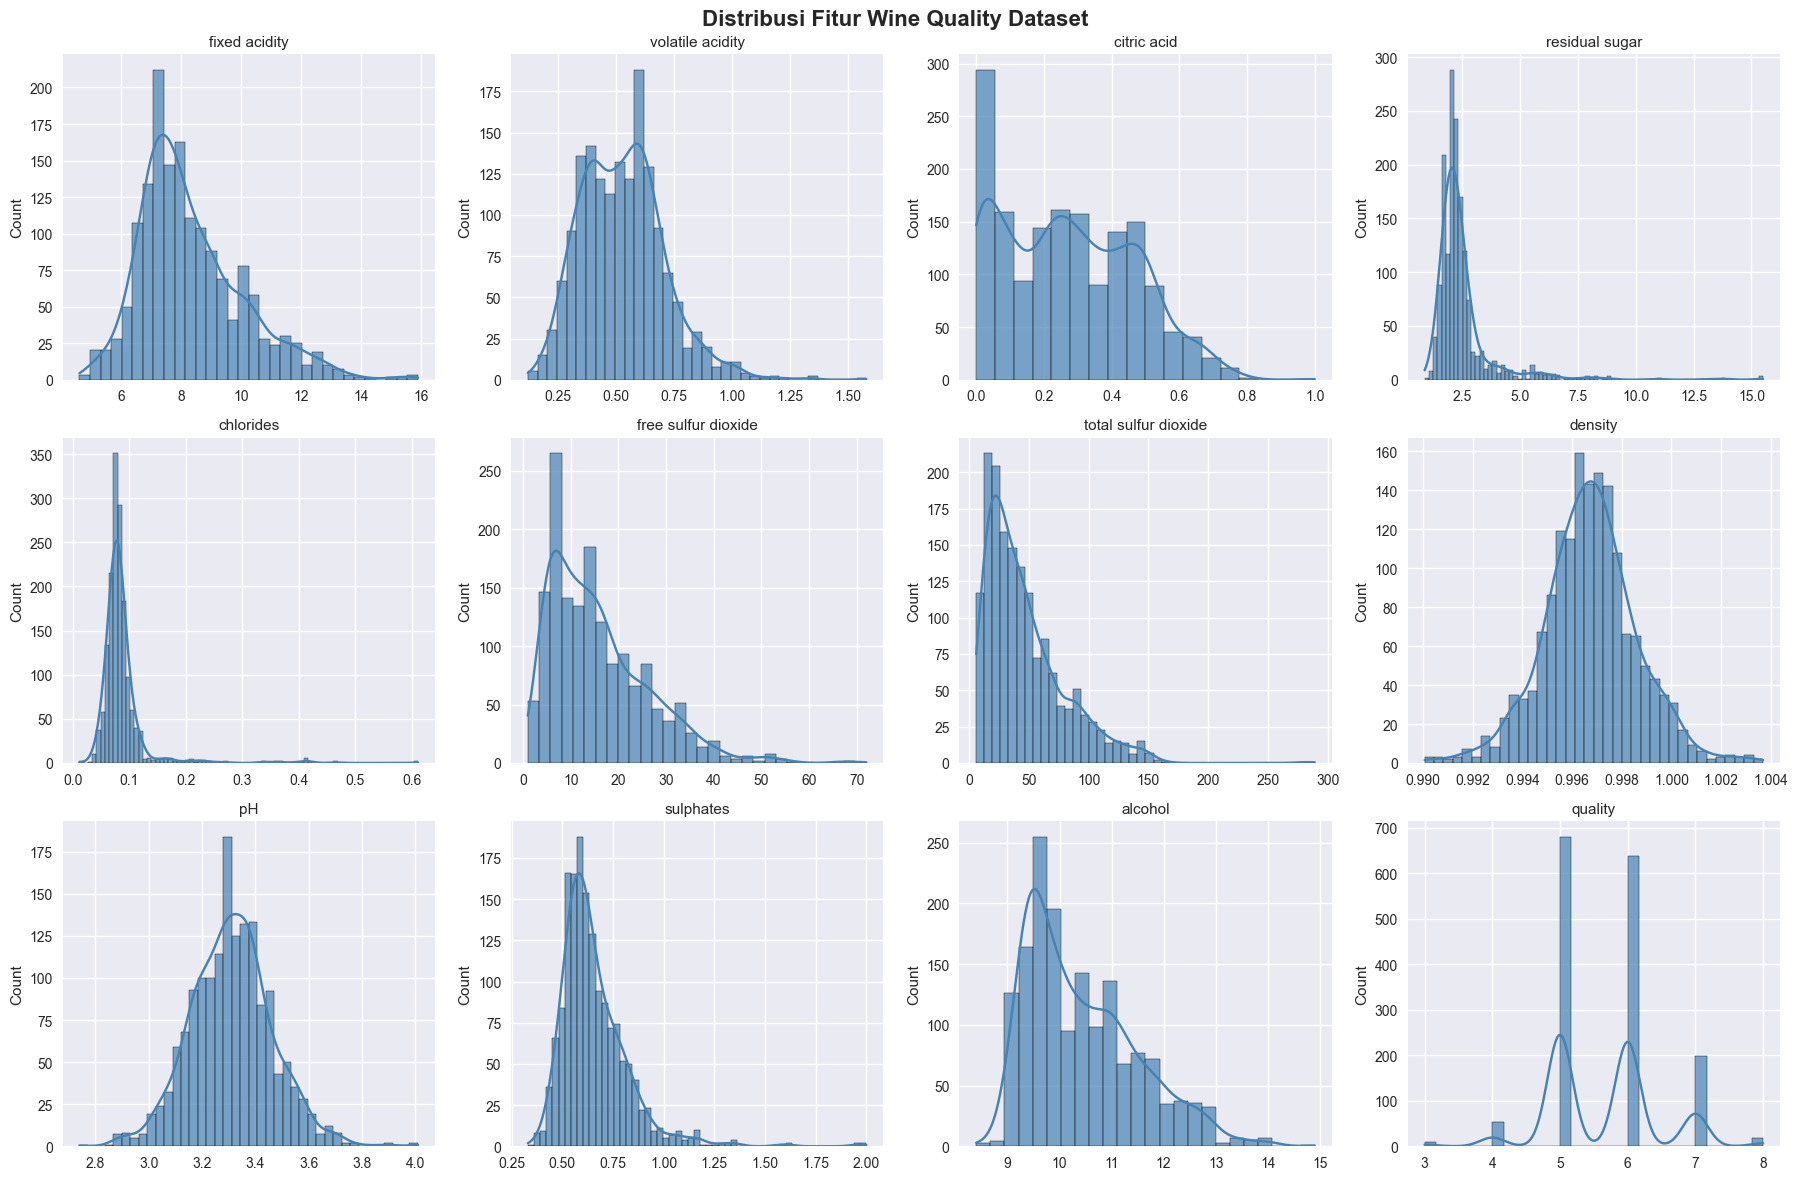

In [7]:
# Distribusi setiap fitur
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Distribusi Fitur Wine Quality Dataset', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    row = idx // 4
    col_idx = idx % 4
    ax = axes[row][col_idx]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

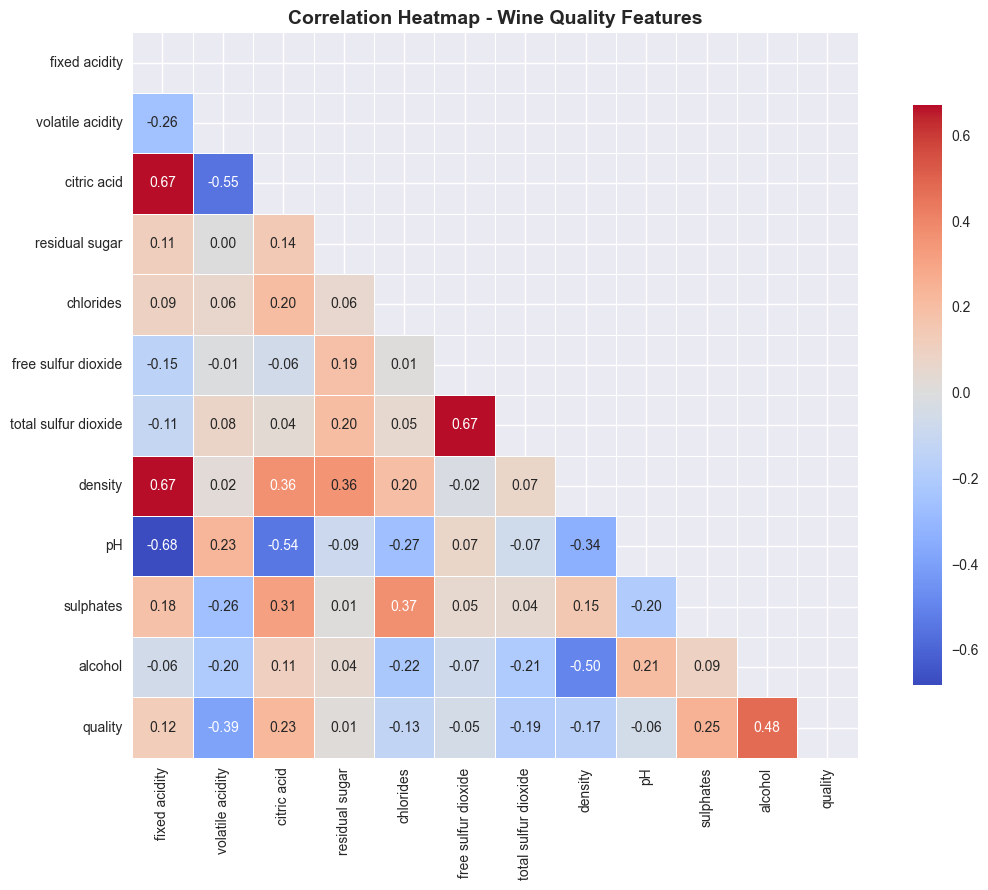


Korelasi fitur dengan Quality (target):
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [8]:
# Correlation Heatmap
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - Wine Quality Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi dengan target
print('\nKorelasi fitur dengan Quality (target):')
print(corr_matrix['quality'].sort_values(ascending=False))

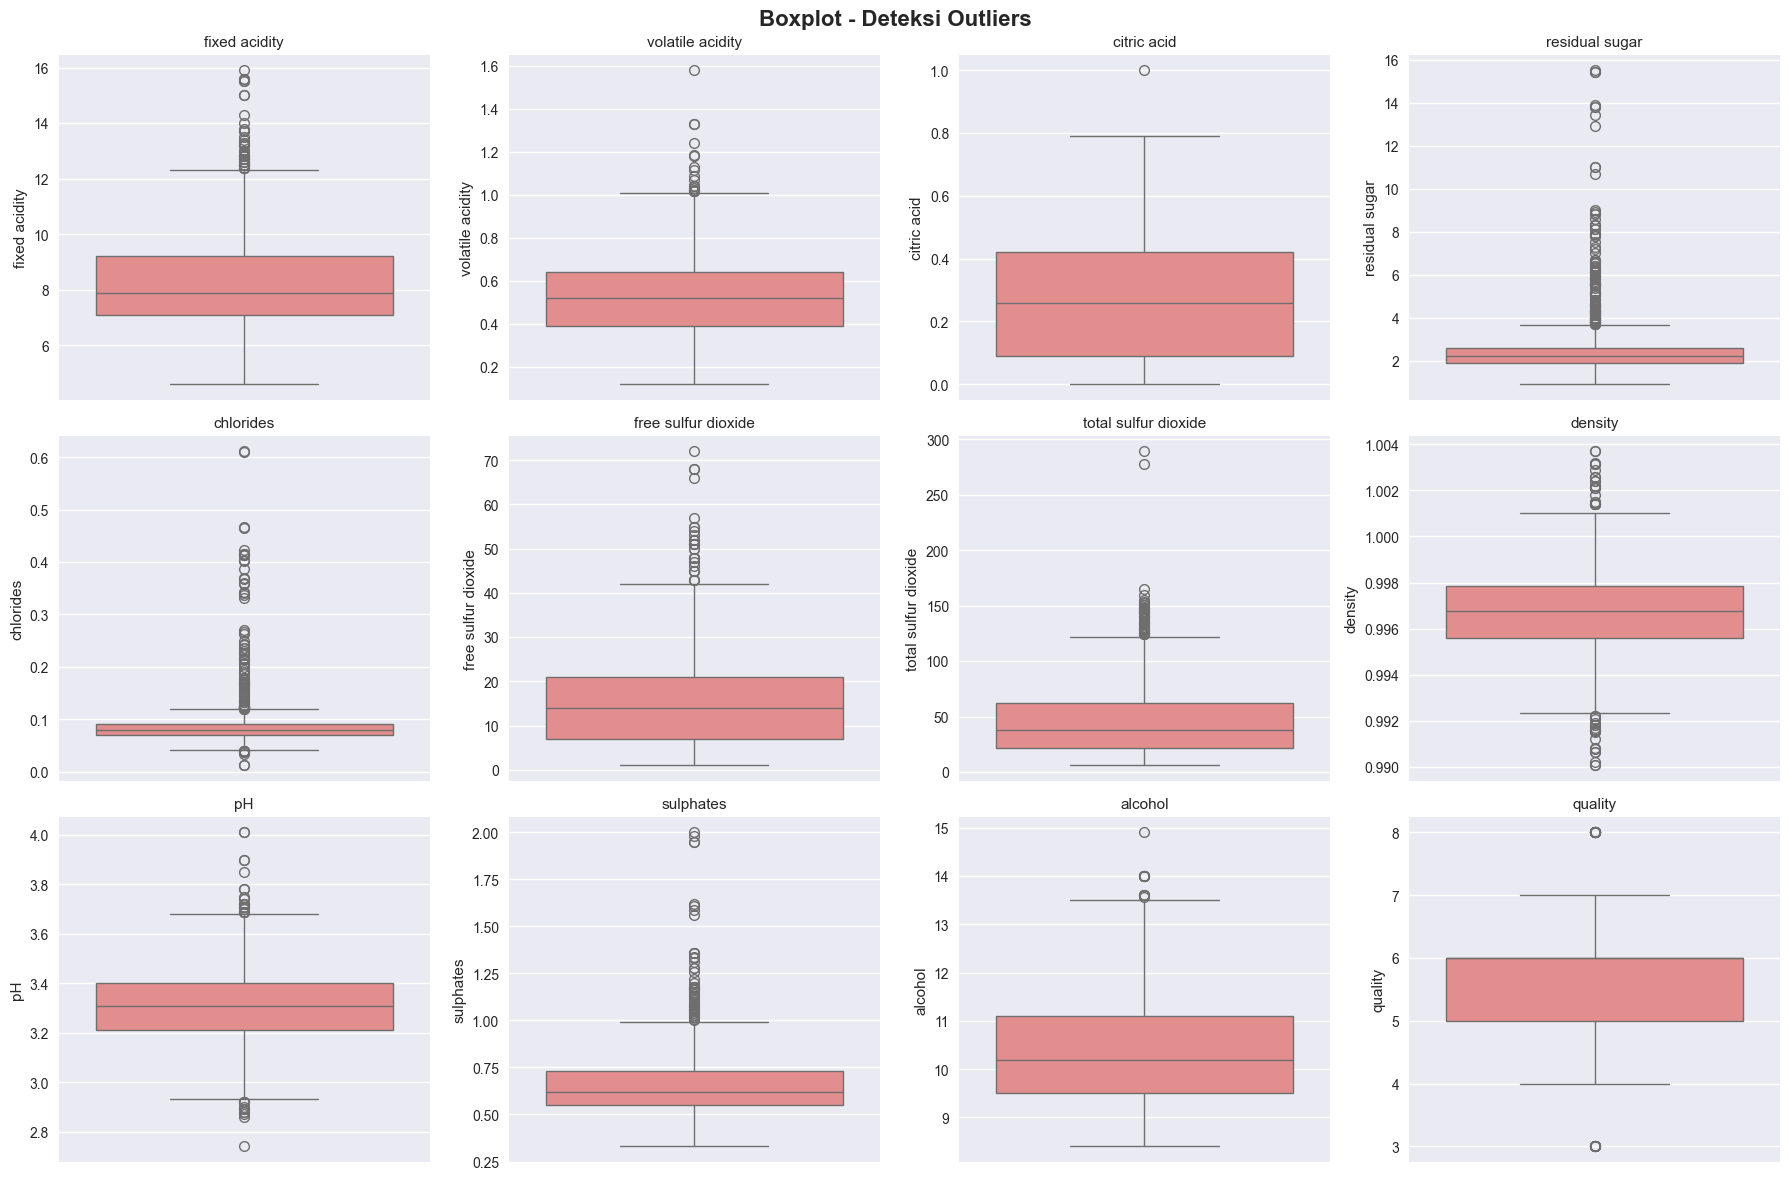

In [9]:
# Boxplot untuk mendeteksi outliers
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Boxplot - Deteksi Outliers', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    row = idx // 4
    col_idx = idx % 4
    ax = axes[row][col_idx]
    sns.boxplot(data=df, y=col, ax=ax, color='lightcoral')
    ax.set_title(col, fontsize=11)

plt.tight_layout()
plt.show()

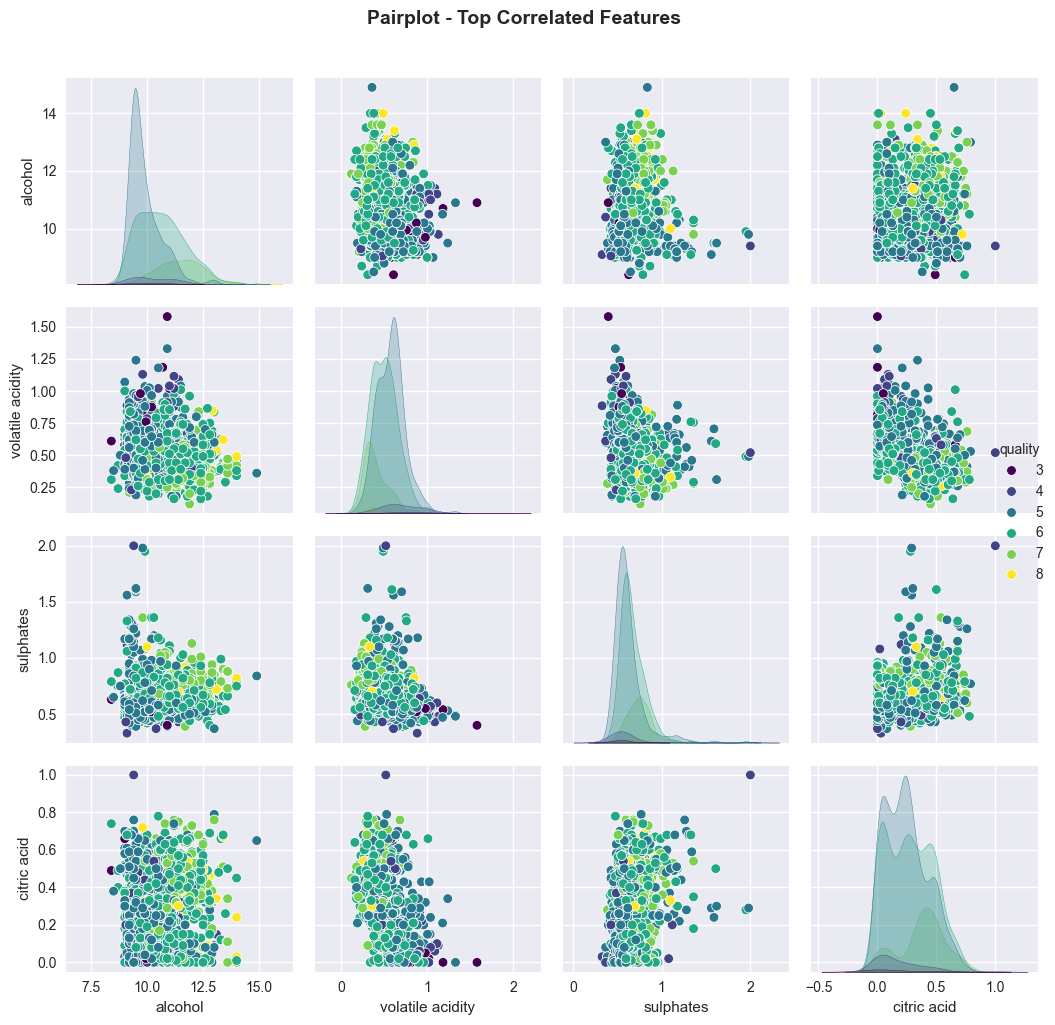

In [10]:
# Pairplot fitur paling berkorelasi dengan quality
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality']
sns.pairplot(df[top_features], hue='quality', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot - Top Correlated Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Insight dari EDA:
1. Dataset memiliki 1599 baris dan 12 kolom (11 fitur + 1 target)
2. Tidak ada missing values
3. Terdapat 240 baris duplikat yang perlu dihapus
4. Quality score terdistribusi normal dengan mayoritas wine berkualitas 5-6
5. Beberapa fitur memiliki outliers signifikan (residual sugar, chlorides, total sulfur dioxide)
6. Fitur yang paling berkorelasi dengan quality: alcohol (positif), volatile acidity (negatif)

---
## 3. Preprocessing
Pada tahap ini kita akan melakukan preprocessing data agar siap untuk pelatihan model.

In [11]:
# Step 1: Hapus duplikat
print(f'Sebelum hapus duplikat: {df.shape[0]} baris')
df_clean = df.drop_duplicates()
print(f'Setelah hapus duplikat: {df_clean.shape[0]} baris')
print(f'Duplikat dihapus: {df.shape[0] - df_clean.shape[0]} baris')
df_clean = df_clean.reset_index(drop=True)

Sebelum hapus duplikat: 1599 baris
Setelah hapus duplikat: 1359 baris
Duplikat dihapus: 240 baris


In [12]:
# Step 2: Handle Outliers menggunakan IQR method
def remove_outliers_iqr(dataframe, columns):
    """Hapus outliers menggunakan metode IQR."""
    df_out = dataframe.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]
    return df_out.reset_index(drop=True)

feature_cols = [col for col in df_clean.columns if col != 'quality']
print(f'Sebelum outlier removal: {df_clean.shape[0]} baris')
df_no_outliers = remove_outliers_iqr(df_clean, feature_cols)
print(f'Setelah outlier removal: {df_no_outliers.shape[0]} baris')
print(f'Outliers dihapus: {df_clean.shape[0] - df_no_outliers.shape[0]} baris')

Sebelum outlier removal: 1359 baris
Setelah outlier removal: 985 baris
Outliers dihapus: 374 baris


Target Distribution (Binary):
quality_label
0    860
1    125
Name: count, dtype: int64



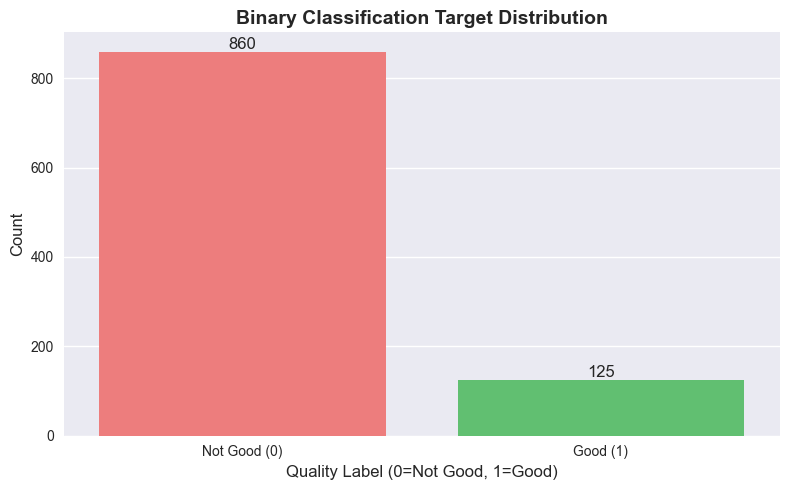

In [13]:
# Step 3: Feature Engineering - Binary Classification
# quality >= 7 -> Good (1), quality < 7 -> Not Good (0)
df_processed = df_no_outliers.copy()
df_processed['quality_label'] = (df_processed['quality'] >= 7).astype(int)

print('Target Distribution (Binary):')
print(df_processed['quality_label'].value_counts())
print()

# Visualisasi distribusi target baru
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_processed, x='quality_label', palette=['#ff6b6b', '#51cf66'])
plt.title('Binary Classification Target Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Quality Label (0=Not Good, 1=Good)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1], ['Not Good (0)', 'Good (1)'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

In [14]:
# Step 4: Separate features and target
X = df_processed.drop(['quality', 'quality_label'], axis=1)
y = df_processed['quality_label']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')

Features shape: (985, 11)
Target shape: (985,)

Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [15]:
# Step 5: Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain target distribution:')
print(y_train.value_counts())
print(f'\nTest target distribution:')
print(y_test.value_counts())

Train set: 788 samples (80.0%)
Test set:  197 samples (20.0%)

Train target distribution:
quality_label
0    688
1    100
Name: count, dtype: int64

Test target distribution:
quality_label
0    172
1     25
Name: count, dtype: int64


In [16]:
# Step 6: Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Setelah Scaling (Statistik Train):')
print(X_train_scaled.describe().round(3))

Setelah Scaling (Statistik Train):
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        788.000           788.000      788.000         788.000   
mean          -0.000             0.000        0.000           0.000   
std            1.001             1.001        1.001           1.001   
min           -2.084            -2.410       -1.381          -2.214   
25%           -0.722            -0.793       -0.934          -0.654   
50%           -0.245            -0.014       -0.040          -0.208   
75%            0.640             0.675        0.798           0.683   
max            2.820             2.921        2.474           3.247   

       chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  \
count    788.000              788.000               788.000  788.000  788.000   
mean       0.000               -0.000                -0.000    0.000    0.000   
std        1.001                1.001                 1.001    1.001    1.001   
m

In [17]:
# Step 7: Simpan data preprocessing
import os

output_dir = 'wine_quality_preprocessing'
os.makedirs(output_dir, exist_ok=True)

# Gabungkan fitur dan target
train_df = pd.concat([X_train_scaled.reset_index(drop=True),
                      y_train.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test_scaled.reset_index(drop=True),
                     y_test.reset_index(drop=True)], axis=1)

# Simpan ke CSV
train_df.to_csv(os.path.join(output_dir, 'train.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test.csv'), index=False)

# Simpan scaler
import joblib
joblib.dump(scaler, os.path.join(output_dir, 'scaler.pkl'))

print(f'Data train disimpan: {train_df.shape}')
print(f'Data test disimpan: {test_df.shape}')
print(f'Scaler disimpan ke: {output_dir}/scaler.pkl')
print('\nPreprocessing selesai!')

Data train disimpan: (788, 12)
Data test disimpan: (197, 12)
Scaler disimpan ke: wine_quality_preprocessing/scaler.pkl

Preprocessing selesai!


---
## Ringkasan Preprocessing

| Langkah | Deskripsi | Hasil |
|---------|-----------|-------|
| 1. Data Loading | Load dataset dari CSV | 1599 baris, 12 kolom |
| 2. Hapus Duplikat | Menghapus baris duplikat | -240 baris |
| 3. Handle Outliers | IQR method pada semua fitur | -374 baris |
| 4. Feature Engineering | Binary classification (quality >= 7) | Target: 0/1 |
| 5. Train-Test Split | 80/20 split, stratified | 788 train, 197 test |
| 6. Feature Scaling | StandardScaler | Mean=0, Std=1 |
| 7. Simpan Data | Export ke CSV + pkl | train.csv, test.csv, scaler.pkl |